# Importing necessary libraries

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import tensorflow
import sklearn

from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *

plt.style.use("seaborn")

pd.options.display.max_rows = 2000
pd.options.display.max_columns = 500

C:\Users\PRETREK\AppData\Local\Temp\ipykernel_28660\2848714450.py:16: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


In [144]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [145]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [146]:
train.sample(2)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
39669,69e88ef179506404,My personal opinion \n\nIs that you're a fucki...,1,0,1,1,1,0
27848,49bb075fe35b70e8,I added this to the BLP board. Going back and ...,0,0,0,0,0,0


In [147]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


# Exploratory Data Analysis

In [148]:
train['y'] = train[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].sum(axis=1) > 0
train.drop(['toxic','severe_toxic','obscene','threat','insult','identity_hate'], inplace=True, axis=1)

In [149]:
train.head()

,id,comment_text,y
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,False
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,False
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",False
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",False
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",False


In [150]:
train.y.unique()

array([False,  True])

<Axes: ylabel='y'>

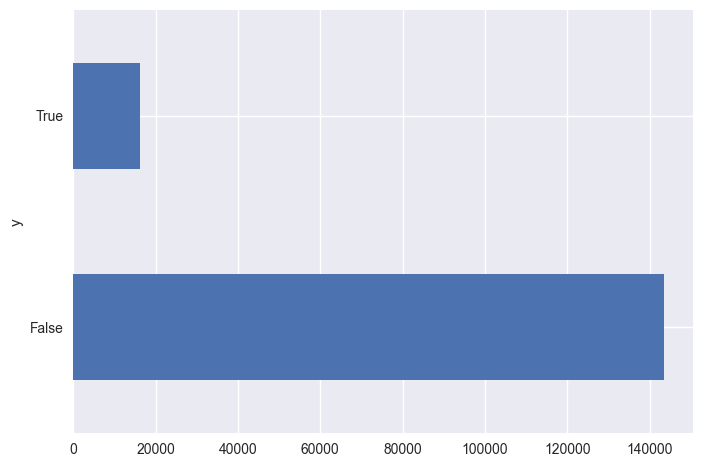

In [151]:
train.y.value_counts().plot(kind='barh')

# Handling Imbalanced Dataset

In [152]:
count_of_toxic_comments =  train[train.y != 0].shape[0]
count_of_toxic_comments

16225

In [153]:
train_toxic = train[train.y != 0]
train_non_toxic = train[train.y == 0].sample(count_of_toxic_comments)

In [154]:
df = pd.concat([train_toxic, train_non_toxic])
df

,id,comment_text,y
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,True
12,0005c987bdfc9d4b,Hey... what is it..\n@ | talk .\nWhat is it......,True
16,0007e25b2121310b,"Bye! \n\nDon't look, come or think of comming ...",True
42,001810bf8c45bf5f,You are gay or antisemmitian? \n\nArchangel WH...,True
43,00190820581d90ce,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",True
...,...,...,...
107257,3d58ad6bff7b6d20,I think these admin should be recalled immedia...,False
158777,f3899829a2442ceb,hi \n\nHi. I found you in categories of users ...,False
59181,9e873e15a57f8e8b,Mangroves Forests are a Terrestrial Biome beca...,False
151386,7c334b3602133ff8,Thanks for experimenting with Wikipedia. Your ...,False


<Axes: ylabel='y'>

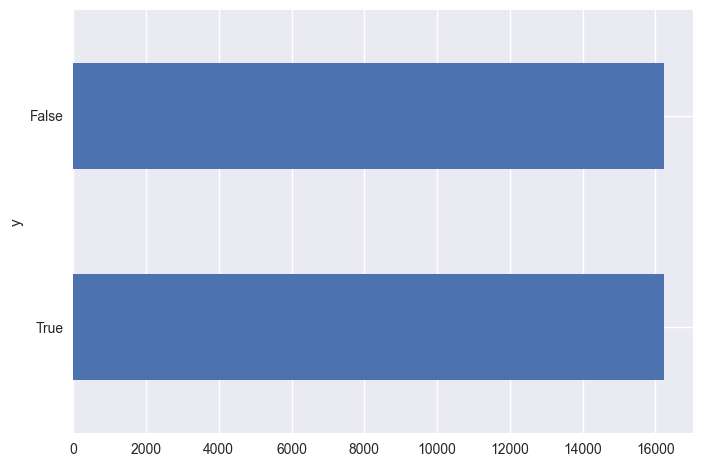

In [155]:
df.y.value_counts().plot(kind='barh')

In [156]:
#word count
df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))

In [157]:
# unique_word_count
df['unique_word_count'] = df['comment_text'].apply(lambda x: len(set(str(x).split())))

In [158]:
from wordcloud import STOPWORDS

In [159]:
# stop_word_count
df['stop_word_count'] = df['comment_text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))

In [160]:
# mean_word_length
df['mean_word_length'] = df['comment_text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

In [161]:
# char_count
df['char_count'] = df['comment_text'].apply(lambda x: len(str(x)))

In [162]:
# punctuation_count
df['punctuation_count'] = df['comment_text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

In [163]:
df.head()

,id,comment_text,y,word_count,unique_word_count,stop_word_count,mean_word_length,char_count,punctuation_count
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,True,8,8,4,4.625000,44,0
12,0005c987bdfc9d4b,Hey... what is it..\n@ | talk .\nWhat is it......,True,53,50,22,5.018868,319,24
16,0007e25b2121310b,"Bye! \n\nDon't look, come or think of comming ...",True,10,10,3,4.600000,57,5
42,001810bf8c45bf5f,You are gay or antisemmitian? \n\nArchangel WH...,True,117,88,54,4.478632,648,28
43,00190820581d90ce,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",True,8,8,3,4.125000,40,2


C:\Users\PRETREK\AppData\Local\Temp\ipykernel_28660\3560099555.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[~TOXIC_COMMENTS][feature], label='Non Toxic', ax=axes[i][0], color='green')
C:\Users\PRETREK\AppData\Local\Temp\ipykernel_28660\3560099555.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

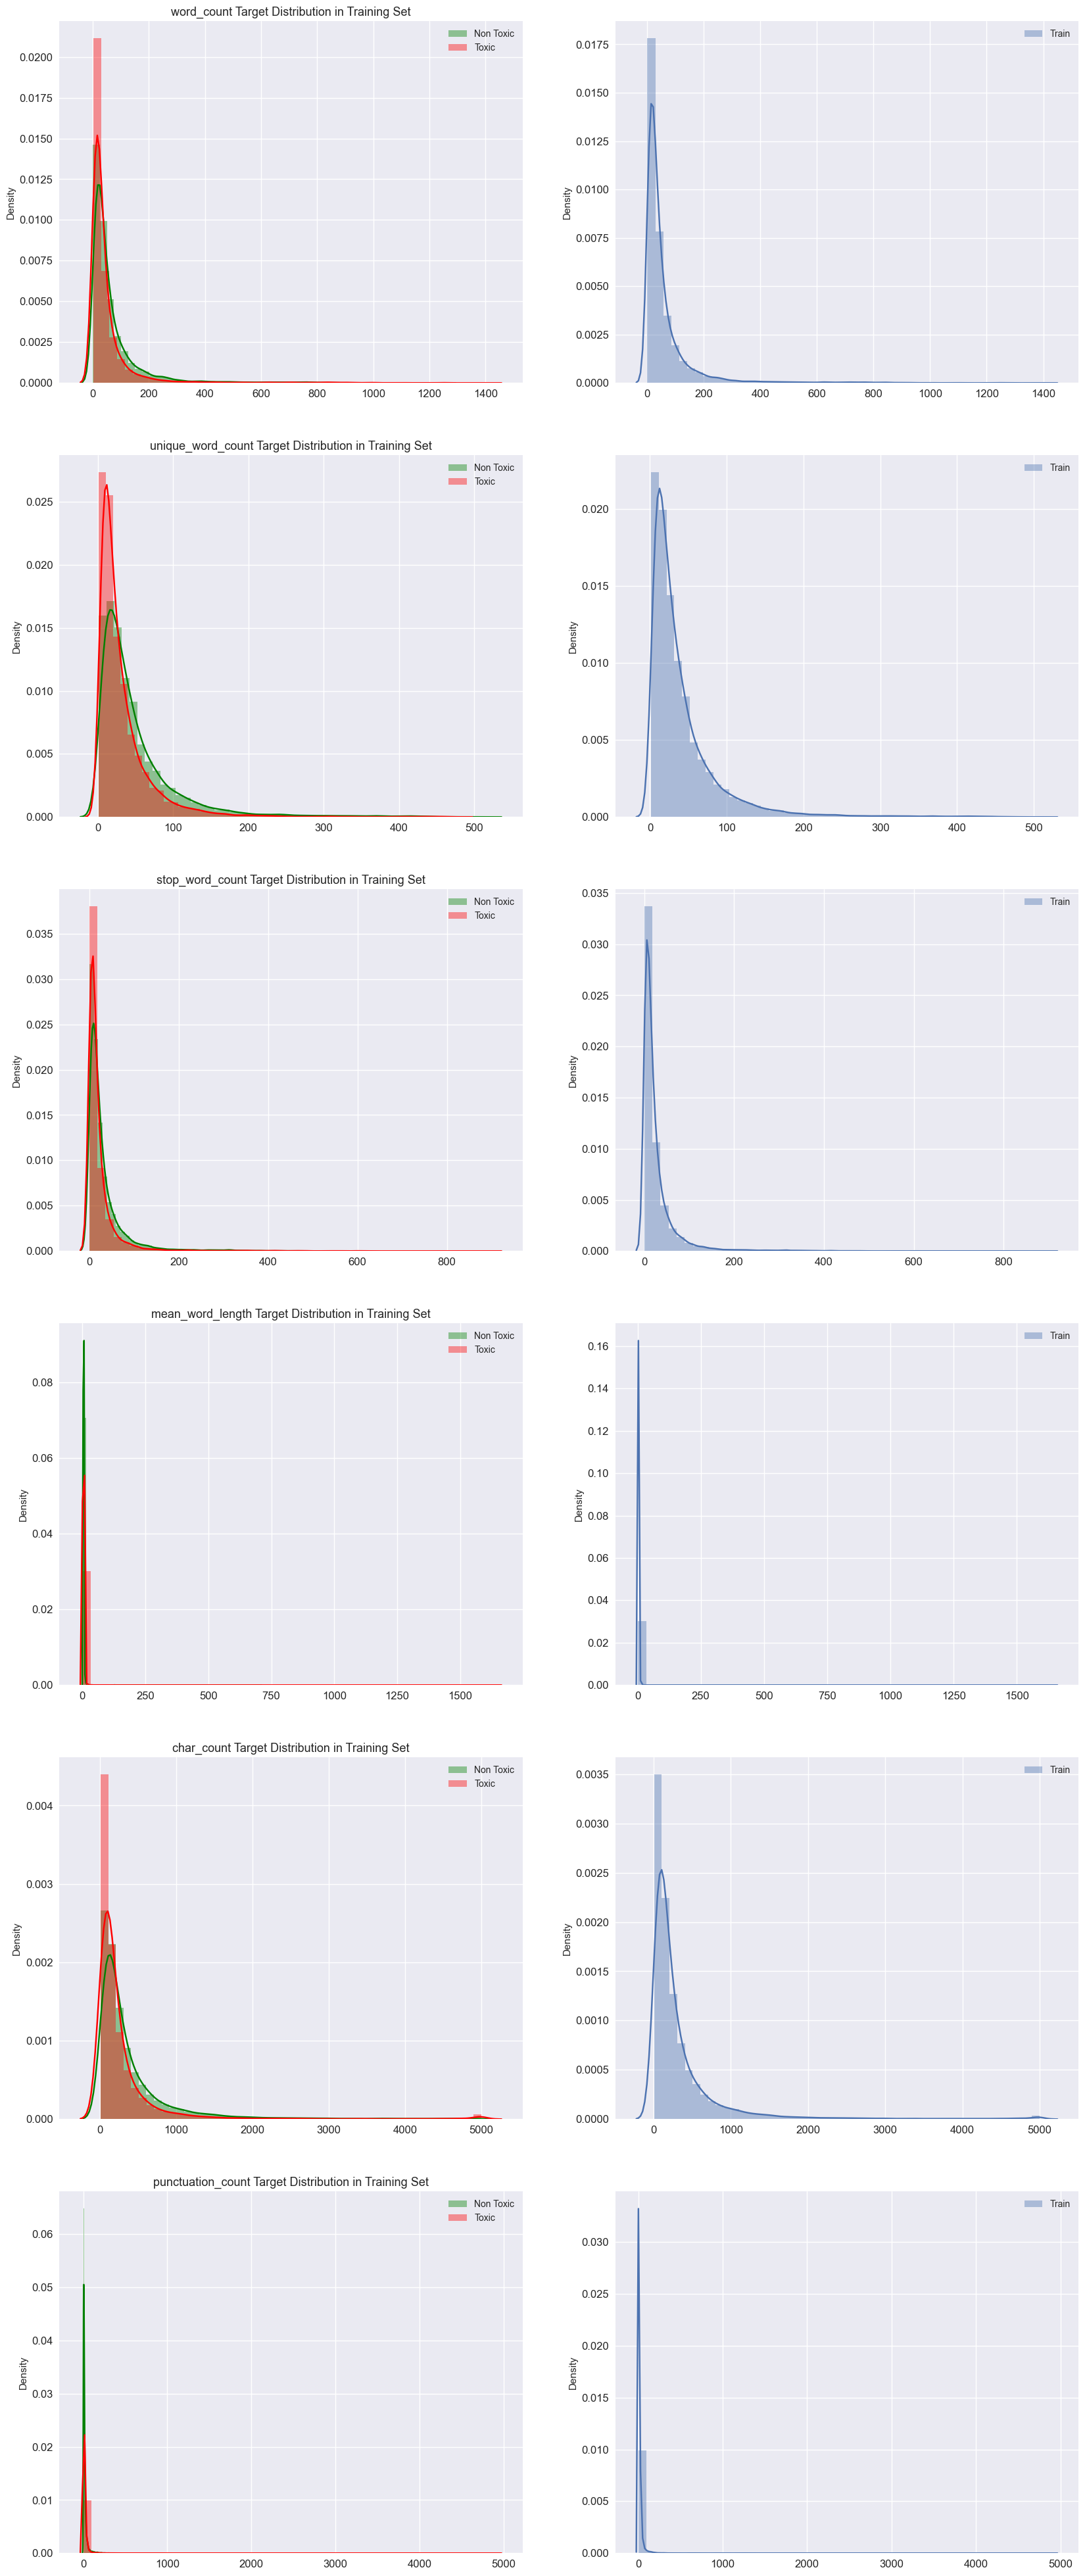

In [164]:
METAFEATURES = ['word_count', 'unique_word_count', 'stop_word_count', 'mean_word_length','char_count', 'punctuation_count']
TOXIC_COMMENTS = df['y'] == 1

fig, axes = plt.subplots(ncols=2, nrows=len(METAFEATURES), figsize=(20, 50), dpi=100)

for i, feature in enumerate(METAFEATURES):
    sns.distplot(df.loc[~TOXIC_COMMENTS][feature], label='Non Toxic', ax=axes[i][0], color='green')
    sns.distplot(df.loc[TOXIC_COMMENTS][feature], label='Toxic', ax=axes[i][0], color='red')

    sns.distplot(df[feature], label='Train', ax=axes[i][1])
    
    for j in range(2):
        axes[i][j].set_xlabel('')
        axes[i][j].tick_params(axis='x', labelsize=12)
        axes[i][j].tick_params(axis='y', labelsize=12)
        axes[i][j].legend()
    
    axes[i][0].set_title(f'{feature} Target Distribution in Training Set', fontsize=13)

plt.show()

In [165]:
df.describe()

,word_count,unique_word_count,stop_word_count,mean_word_length,char_count,punctuation_count
count,32450.000000,32450.000000,32450.000000,32450.000000,32450.000000,32450.000000
mean,60.937966,41.527858,27.476857,5.056203,354.791618,15.312666
std,103.985033,50.183484,47.165796,15.620174,612.221644,61.018545
min,1.000000,1.000000,0.000000,1.000000,6.000000,0.000000
25%,13.000000,12.000000,5.000000,4.216216,76.000000,3.000000
50%,29.000000,26.000000,13.000000,4.605598,166.000000,7.000000
75%,63.000000,50.000000,30.000000,5.042478,364.000000,15.000000
max,1411.000000,512.000000,902.000000,1655.000000,5000.000000,4942.000000


In [166]:
train.sample(2)

,id,comment_text,y
70689,bd2cfa809bdb1793,"""\nActually, I was on your side until you took...",False
124361,99420d558df77d5a,Chaldeans are Assyrians \n\nBut some don't wis...,False


In [167]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [168]:
for i in range(1):
    n = np.random.randint(159571)
    labels = train.iloc[n:n+1,2:-1]
    sample = train['comment_text'][n]
    print('-'*80)
    print(f'Labels:\n{labels}\n\nSample:\n{sample}')

--------------------------------------------------------------------------------
Labels:
       toxic  severe_toxic  obscene  threat  insult
95447      0             0        0       0       0

Sample:
By all means, if someone has found other good secondary sources about this, add them!  As contentious as this topic has been, people shouldn't be holding out on the sources that have influenced their opinions - it makes it much harder to generate consensus.


In [169]:
#length analysis
train['len_text'] = train['comment_text'].apply(lambda x: len(x.split(' ')))

In [170]:
train.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate,len_text
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805,67.866962
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420,100.520204
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2273.000000


In [171]:
for label in train.columns[2:]:
    print(train[label].value_counts(), '\n')

toxic
0    144277
1     15294
Name: count, dtype: int64 

severe_toxic
0    157976
1      1595
Name: count, dtype: int64 

obscene
0    151122
1      8449
Name: count, dtype: int64 

threat
0    159093
1       478
Name: count, dtype: int64 

insult
0    151694
1      7877
Name: count, dtype: int64 

identity_hate
0    158166
1      1405
Name: count, dtype: int64 

len_text
5       3621
6       3350
7       3189
4       3133
8       2993
10      2900
9       2895
11      2879
13      2740
12      2693
14      2668
16      2648
15      2602
17      2485
19      2438
18      2388
20      2341
21      2320
22      2231
25      2189
23      2153
24      2097
26      2058
29      2034
27      1986
31      1972
30      1965
28      1935
32      1846
33      1793
34      1657
35      1641
36      1627
37      1533
39      1438
38      1433
41      1394
40      1392
42      1343
47      1282
44      1267
45      1262
43      1259
46      1211
48      1209
49      1161
52      1159
50      1135


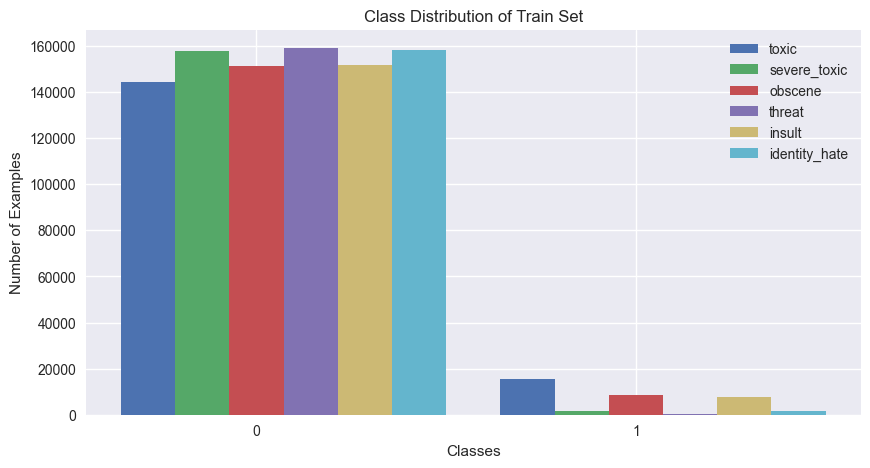

In [172]:
# Get the class distribution for each column
class_distributions = []
for i in range(2, 8):
    class_distributions.append(train.iloc[:, i].value_counts())

# Create a combined bar chart
labels = class_distributions[0].index
num_columns = len(class_distributions)
width = 1 / (num_columns + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for i, class_dist in enumerate(class_distributions):
    x = np.arange(len(labels)) + (i + 1) * width
    bars = ax.bar(x, class_dist, width, label=train.columns[i+2])

ax.set_ylabel('Number of Examples')
ax.set_xlabel('Classes')
ax.set_title('Class Distribution of Train Set')
ax.set_xticks(x - width * (num_columns / 2))
ax.set_xticklabels(labels)
ax.legend()

plt.show()

In [173]:
train.loc[train['len_text'] >1300, 'comment_text'].sample(1).values

array(['Take that! \n\nIN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE ASS IN THE AS

In [174]:
def count(max_int,min_int):
    i = len(train.loc[train['len_text']<max_int, 'len_text'])
    j = len(train.loc[train['len_text']<min_int, 'len_text'])
    return print(f'The number of texts {i-j} in the interval with the length of words {max_int} and {min_int}')

In [175]:
count(250,0)

The number of texts 152730 in the interval with the length of words 250 and 0


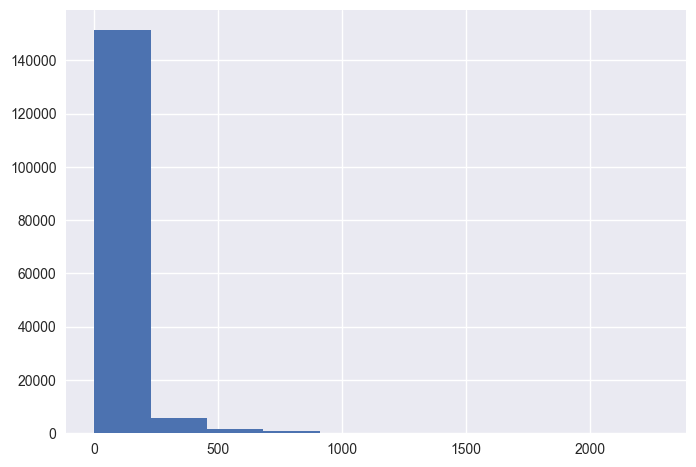

In [176]:
plt.hist(train['len_text']);

# Tokenization and Vectorization

In [177]:
def custom_standardization(sentence):
    sample = tensorflow.strings.lower(sentence)
    sample = tensorflow.strings.regex_replace(sample, '\W', ' ')
    sample = tensorflow.strings.regex_replace(sample, '\d', ' ')
    return tensorflow.strings.regex_replace(sample,
                         '[%s]'%re.escape(string.punctuation), '')

max_features = 10000
sequence_length = 250

vectorize_layer = tensorflow.keras.layers.TextVectorization(
                        standardize=custom_standardization,
                        split='whitespace',
                        max_tokens=max_features,
                        output_mode='int',
                        output_sequence_length=sequence_length,
                        encoding='utf-8')
vectorize_layer.adapt(train['comment_text'])

In [178]:
for i in range(1):
    sample = np.random.randint(159571)
    print(f"Before standartization:\n{train['comment_text'][sample]}")
    print('-'*80)
    print(f"After standartization:\n{custom_standardization(train['comment_text'][sample])}")
    print('-'*80)
    print(f"After vectorization:\n{vectorize_layer(train['comment_text'][sample])}")
    print('*'*80)

Before standartization:
"

I'm still waiting on you to cite your source for the allegation that whether something is convex or concave depends on the perspective of the observer (or whether it's outward or inward, or however you want to phrase it).  My position is that there is no ambiguity in describing it as simply ""convex.""  I don't think the Turner and Godfray articles are correct, and just use a different phrasing.  I'm alleging that they're just outright wrong. -   "
--------------------------------------------------------------------------------
After standartization:
b'   i m still waiting on you to cite your source for the allegation that whether something is convex or concave depends on the perspective of the observer  or whether it s outward or inward  or however you want to phrase it    my position is that there is no ambiguity in describing it as simply   convex     i don t think the turner and godfray articles are correct  and just use a different phrasing   i m allegin

# Model Fitting

In [179]:
from sklearn.model_selection import train_test_split

In [180]:
x = train.iloc[:,1:2]
X = np.array(vectorize_layer(x))
X.shape

(159571, 250)

In [183]:
X

array([[ 662,   78,    2, ...,    0,    0,    0],
       [ 147,    1,   52, ...,    0,    0,    0],
       [ 403,  413,    4, ...,    0,    0,    0],
       ...,
       [   1, 6940, 4894, ...,    0,    0,    0],
       [   6,   11,  559, ...,    0,    0,    0],
       [   6,    4,  138, ...,    0,    0,    0]], dtype=int64)

In [184]:
Y = np.array(train.iloc[:,2:-1])
Y.shape

(159571, 6)

In [185]:
Y

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int64)

In [186]:
a = test.iloc[:,1:2]
A= np.array(vectorize_layer(a))
A.shape

(153164, 250)

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print('-'*50)
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (127656, 250), y_train: (127656, 6)
--------------------------------------------------
X_test: (31915, 250), y_test: (31915, 6)


# Model Building

In [188]:
embedding_dim = 16

In [189]:
model = Sequential()
model.add(Embedding(max_features+1, embedding_dim))
model.add(Dropout(0.2))
model.add(GlobalAveragePooling1D())
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(6, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
             optimizer='Adam',
             metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, None, 16)          160016    
                                                                 
 dropout_2 (Dropout)         (None, None, 16)          0         
                                                                 
 global_average_pooling1d_1   (None, 16)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dropout_3 (Dropout)         (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                272       
                                                                 
 dense_3 (Dense)             (None, 6)                 102       
                                                      

In [190]:
epochs = 10
history = model.fit(X_train, 
                    y_train, 
                    epochs=epochs,
                    batch_size=512,
                    validation_data=(X_test, y_test))

Epoch 1/10
250/250 [==============================] - 12s 29ms/step - loss: 0.3386 - accuracy: 0.4142 - val_loss: 0.1445 - val_accuracy: 0.9945
Epoch 2/10
250/250 [==============================] - 7s 28ms/step - loss: 0.1404 - accuracy: 0.9939 - val_loss: 0.1358 - val_accuracy: 0.9945
Epoch 3/10
250/250 [==============================] - 8s 32ms/step - loss: 0.1352 - accuracy: 0.9938 - val_loss: 0.1315 - val_accuracy: 0.9946
Epoch 4/10
250/250 [==============================] - 8s 32ms/step - loss: 0.1304 - accuracy: 0.9939 - val_loss: 0.1263 - val_accuracy: 0.9946
Epoch 5/10
250/250 [==============================] - 8s 32ms/step - loss: 0.1249 - accuracy: 0.9938 - val_loss: 0.1194 - val_accuracy: 0.9946
Epoch 6/10
250/250 [==============================] - 8s 32ms/step - loss: 0.1159 - accuracy: 0.9937 - val_loss: 0.1088 - val_accuracy: 0.9946
Epoch 7/10
250/250 [==============================] - 8s 32ms/step - loss: 0.1030 - accuracy: 0.9893 - val_loss: 0.0950 - val_accuracy: 0.991

In [191]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [192]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_model = range(1, len(acc)+1) 

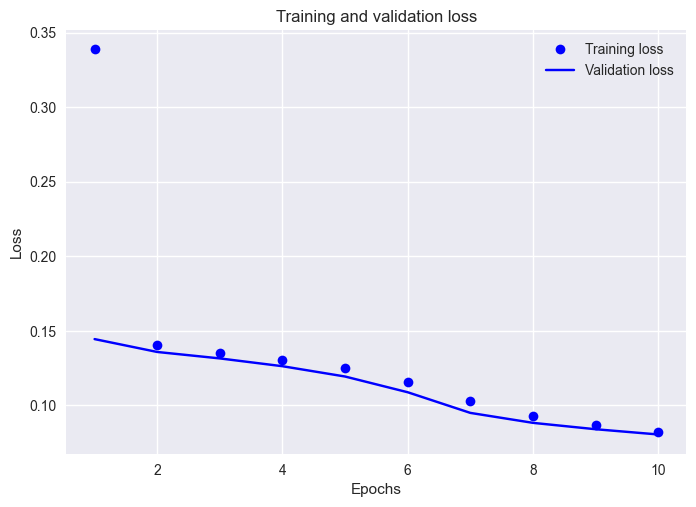

In [193]:
plt.plot(epochs_model, loss, 'bo', label = 'Training loss')
plt.plot(epochs_model, val_loss, 'b', label = 'Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

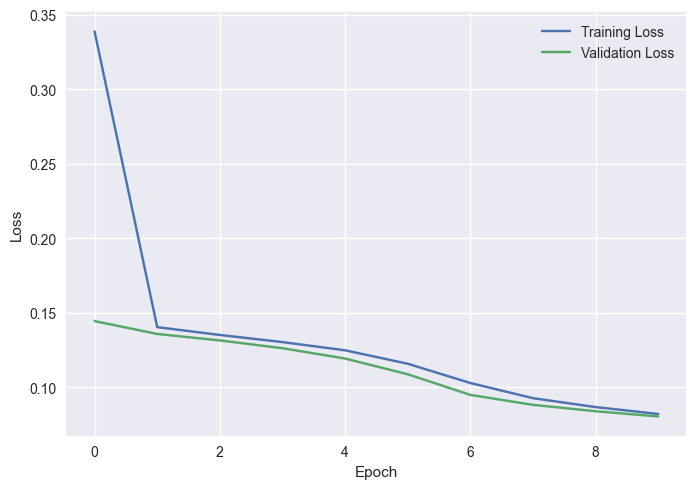

In [194]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

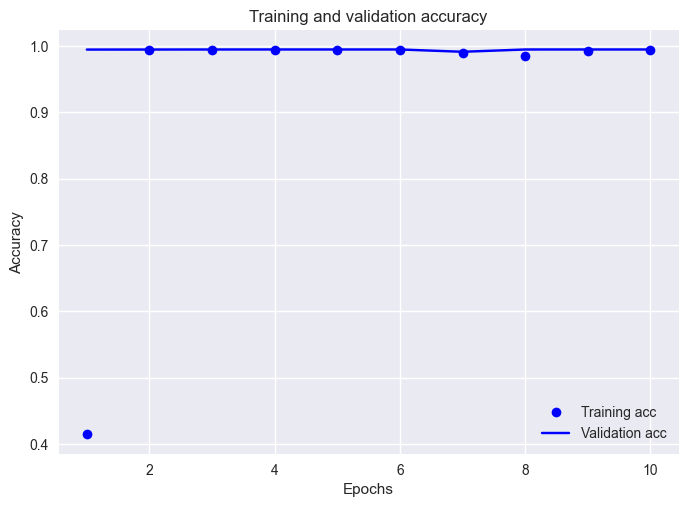

In [195]:
plt.plot(epochs_model, acc, 'bo', label = 'Training acc')
plt.plot(epochs_model, val_acc, 'b', label = 'Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()

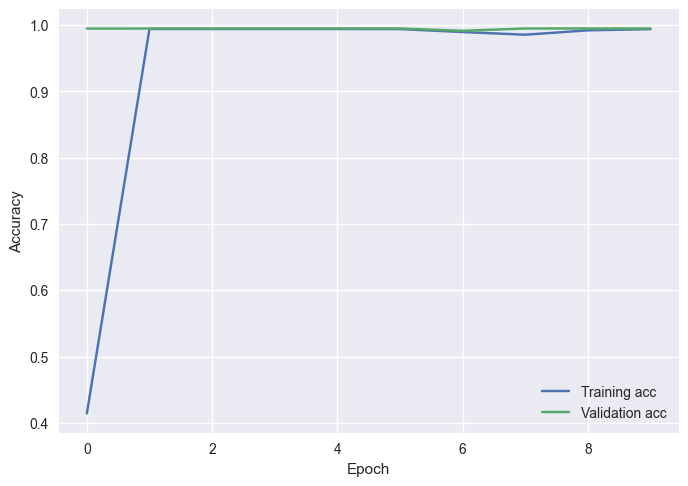

In [196]:
plt.plot(history.history['accuracy'], label='Training acc')
plt.plot(history.history['val_accuracy'], label='Validation acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Model Prediction

In [197]:
for i in range(1):
    n = np.random.randint(159571)
    labels = train.iloc[n:n+1,2:-1]
    sample = train['comment_text'][n]
    print('-'*80)
    print(f'Labels:\n{labels}\n\nSample:\n{sample}')
    print('Predict this sample with our model')
    print(dict(zip(list(labels), model.predict(X[n:n+1])[0])))

--------------------------------------------------------------------------------
Labels:
        toxic  severe_toxic  obscene  threat  insult  identity_hate
113250      0             0        0       0       0              0

Sample:
"
 Congrats, well deserved.  Great stuff!  (talk) "
Predict this sample with our model
1/1 [==============================] - 0s 71ms/step
{'toxic': 0.065174915, 'severe_toxic': 0.0053649726, 'obscene': 0.032053065, 'threat': 0.003435112, 'insult': 0.029144453, 'identity_hate': 0.007614782}


In [198]:
predict = model.predict(A)

4787/4787 [==============================] - 5s 973us/step


In [199]:
predict.shape

(153164, 6)

In [200]:
label = pd.DataFrame(predict, columns=list(labels))
ids = test['id']
submission = pd.concat([ids, label], axis=1)
submission

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.996365,0.465483,0.974151,0.125813,0.937152,0.328903
1,0000247867823ef7,0.038543,0.003457,0.020079,0.002424,0.018408,0.005313
2,00013b17ad220c46,0.136693,0.009368,0.061330,0.005143,0.055335,0.012018
3,00017563c3f7919a,0.007141,0.000530,0.003567,0.000539,0.002782,0.001053
4,00017695ad8997eb,0.097147,0.007168,0.045255,0.004222,0.041041,0.009659
...,...,...,...,...,...,...,...
153159,fffcd0960ee309b5,0.196379,0.012877,0.086217,0.006556,0.077661,0.015583
153160,fffd7a9a6eb32c16,0.110464,0.007728,0.050330,0.004401,0.046131,0.010298
153161,fffda9e8d6fafa9e,0.003037,0.000180,0.001428,0.000213,0.001030,0.000408
153162,fffe8f1340a79fc2,0.008956,0.000588,0.004313,0.000536,0.003562,0.001142


In [201]:
threshold=0.5
label = pd.DataFrame(predict, columns=list(labels)).apply(lambda x: (x > threshold).astype(int))
ids = test['id']
submission = pd.concat([ids, label], axis=1)
submission

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,1,0,1,0,1,0
1,0000247867823ef7,0,0,0,0,0,0
2,00013b17ad220c46,0,0,0,0,0,0
3,00017563c3f7919a,0,0,0,0,0,0
4,00017695ad8997eb,0,0,0,0,0,0
...,...,...,...,...,...,...,...
153159,fffcd0960ee309b5,0,0,0,0,0,0
153160,fffd7a9a6eb32c16,0,0,0,0,0,0
153161,fffda9e8d6fafa9e,0,0,0,0,0,0
153162,fffe8f1340a79fc2,0,0,0,0,0,0
